Starting training...
Episode 100000/10000000 - Average Reward per Bet: -0.1056
Episode 200000/10000000 - Average Reward per Bet: -0.0973
Episode 300000/10000000 - Average Reward per Bet: -0.0959
Episode 400000/10000000 - Average Reward per Bet: -0.0921
Episode 500000/10000000 - Average Reward per Bet: -0.0905
Episode 600000/10000000 - Average Reward per Bet: -0.0900
Episode 700000/10000000 - Average Reward per Bet: -0.0887
Episode 800000/10000000 - Average Reward per Bet: -0.0868
Episode 900000/10000000 - Average Reward per Bet: -0.0860
Episode 1000000/10000000 - Average Reward per Bet: -0.0857
Episode 1100000/10000000 - Average Reward per Bet: -0.0852
Episode 1200000/10000000 - Average Reward per Bet: -0.0853
Episode 1300000/10000000 - Average Reward per Bet: -0.0855
Episode 1400000/10000000 - Average Reward per Bet: -0.0854
Episode 1500000/10000000 - Average Reward per Bet: -0.0848
Episode 1600000/10000000 - Average Reward per Bet: -0.0844
Episode 1700000/10000000 - Average Reward pe

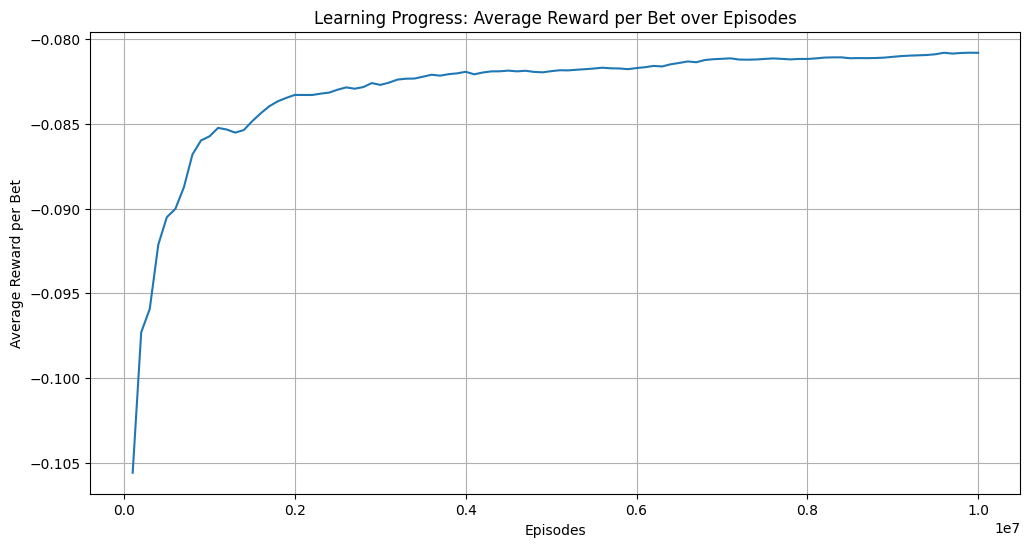

Model saved as 'blackjack_model.pkl'.
Model loaded for evaluation.

Evaluation over 100000 episodes:
Win %: 43.25%
Loss %: 47.93%
Draw %: 8.82%
Average Reward per Bet (%): -4.68%


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

# ---------------------------
# 1. Training with Monte Carlo
# ---------------------------
env = gym.make("Blackjack-v1")

# Q: dictionary mapping (state, action) -> estimated return
Q = {}
# To store the cumulative returns and counts for first-visit updates
returns_sum = {}
returns_count = {}

# Derived policy: state -> best action (0: stick, 1: hit)
policy = {}

# Hyperparameters
N_EPISODES = 10_000_000
epsilon = 0.1  # for epsilon-soft exploration

# Lists to track progress (plotting average reward per bet)
plot_x = []
avg_reward_per_bet = []
cumulative_reward = 0
total_bets = 0

def get_action(state):
    # If the state has a derived policy, use it most of the time
    if state in policy and np.random.rand() > epsilon:
        return policy[state]
    # Otherwise choose randomly (epsilon exploration)
    return np.random.choice([0, 1])

print("Starting training...")
for i_episode in range(1, N_EPISODES + 1):
    episode = []
    state, _ = env.reset()
    
    # --- Check for immediate termination (e.g. natural blackjack) ---
    # Instead of unconditionally entering the loop, we take one step first.
    action = get_action(state)
    next_state, reward, done, truncated, _ = env.step(action)
    episode.append((state, action, reward))
    
    if not done:
        state = next_state
        while not done:
            action = get_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
    # If the environment terminated immediately, we have recorded one pseudo-transition.

    # Calculate return for the episode (the reward is only nonzero at termination)
    G = sum([step[2] for step in episode])

    # First-visit Monte Carlo update: update each (state, action) only on its first occurrence.
    visited_state_actions = set()
    for state, action, _ in episode:
        if (state, action) not in visited_state_actions:
            visited_state_actions.add((state, action))
            # Initialize if first time seeing this (state, action)
            if (state, action) not in returns_sum:
                returns_sum[(state, action)] = 0.0
                returns_count[(state, action)] = 0
            returns_sum[(state, action)] += G
            returns_count[(state, action)] += 1
            Q[(state, action)] = returns_sum[(state, action)] / returns_count[(state, action)]
            # Update policy greedily with respect to Q for the given state
            # Allowed actions are only [0, 1] in this environment.
            actions = [0, 1]
            Q_values = [Q.get((state, a), 0) for a in actions]
            best_action = actions[np.argmax(Q_values)]
            policy[state] = best_action

    cumulative_reward += G
    total_bets += 1

    # Log progress every 100,000 episodes.
    if i_episode % 100_000 == 0:
        avg = cumulative_reward / total_bets
        avg_reward_per_bet.append(avg)
        plot_x.append(i_episode)
        print(f"Episode {i_episode}/{N_EPISODES} - Average Reward per Bet: {avg:.4f}")

# Plot the learning progress.
plt.figure(figsize=(12, 6))
plt.plot(plot_x, avg_reward_per_bet)
plt.xlabel("Episodes")
plt.ylabel("Average Reward per Bet")
plt.title("Learning Progress: Average Reward per Bet over Episodes")
plt.grid(True)
plt.show()

# ---------------------------
# 2. Save the trained model using pickle
# ---------------------------
with open("blackjack_model-v1.pkl", "wb") as f:
    pickle.dump((Q, policy), f)
print("Model saved as 'blackjack_model.pkl'.")

# ---------------------------
# 3. Evaluate the saved model
# ---------------------------
# Load the model
with open("blackjack_model-v1.pkl", "rb") as f:
    Q_loaded, policy_loaded = pickle.load(f)
print("Model loaded for evaluation.")

# Evaluation settings
N_TEST_EPISODES = 100_000
win, loss, draw = 0, 0, 0
cumulative_reward_eval = 0
total_bets_eval = 0

for _ in range(N_TEST_EPISODES):
    state, _ = env.reset()
    
    # As in training, take an initial step to handle any immediate termination.
    action = policy_loaded.get(state, 0)  # default to 'stick' if unseen
    next_state, reward, done, truncated, _ = env.step(action)
    # If the episode ends immediately, record the pseudo-transition.
    if done:
        final_reward = reward
    else:
        state = next_state
        while not done:
            action = policy_loaded.get(state, 0)
            state, reward, done, truncated, _ = env.step(action)
        final_reward = reward

    cumulative_reward_eval += final_reward
    total_bets_eval += 1
    if final_reward > 0:
        win += 1
    elif final_reward < 0:
        loss += 1
    else:
        draw += 1

win_perc = (win / N_TEST_EPISODES) * 100
loss_perc = (loss / N_TEST_EPISODES) * 100
draw_perc = (draw / N_TEST_EPISODES) * 100
avg_reward_eval = (cumulative_reward_eval / total_bets_eval) * 100  # expressed as a percentage

print("\nEvaluation over", N_TEST_EPISODES, "episodes:")
print(f"Win %: {win_perc:.2f}%")
print(f"Loss %: {loss_perc:.2f}%")
print(f"Draw %: {draw_perc:.2f}%")
print(f"Average Reward per Bet (%): {avg_reward_eval:.2f}%")

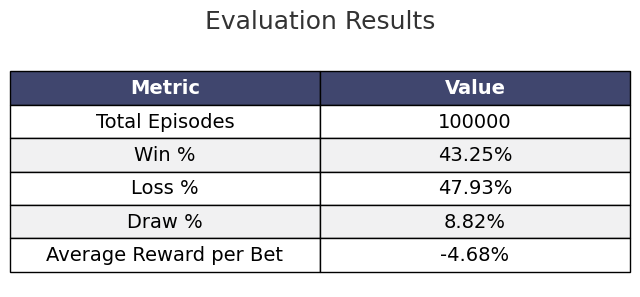

In [ ]:
# Assuming these variables are already computed from your evaluation:
# N_TEST_EPISODES, win_perc, loss_perc, draw_perc, avg_reward_eval

# Prepare table data
table_data = [
    ["Total Episodes", N_TEST_EPISODES],
    ["Win %", f"{win_perc:.2f}%"],
    ["Loss %", f"{loss_perc:.2f}%"],
    ["Draw %", f"{draw_perc:.2f}%"],
    ["Average Reward per Bet", f"{avg_reward_eval:.2f}%"]
]

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')  # Turn off the axis

# Create the table and customize it
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 cellLoc='center', loc='center')

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2)

# Color the header and rows for a beautiful look
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor("#40466e")
        cell.set_text_props(color="w", weight="bold")
    else:
        # Alternate row colors for a more colorful effect
        if row % 2 == 0:
            cell.set_facecolor("#f1f1f2")
        else:
            cell.set_facecolor("#ffffff")

# Set a title with custom styling
plt.title("Evaluation Results", fontsize=18, color="#333333", pad=20)

# Save the figure as an image file in the 'results' folder
plt.savefig("results/evaluation_results.png", bbox_inches="tight", dpi=300)
plt.show()